In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [ ]:
from functools import partial

from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary
from statsforecast.models import AutoARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.processing import make_future_dataframe

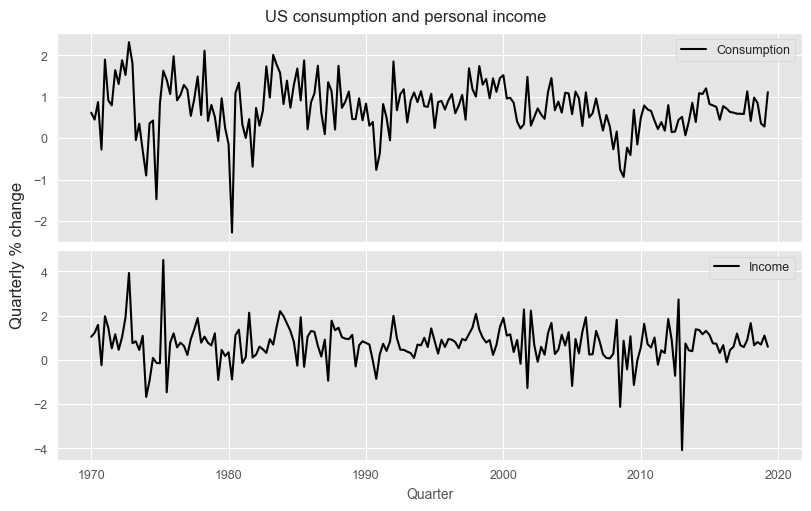

In [3]:
us_change = (
    pd.read_csv('US_change.csv', parse_dates=["ds"])
    .rename(columns={"y": "Consumption"})
    [["unique_id", "ds", "Consumption", "Income"]]
)

fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=us_change, x="ds", y="Consumption", color="black",
    label="Consumption", ax=axes[0])
sns.lineplot(data=us_change, x="ds", y="Income", color="black",
    label="Income", ax=axes[1])
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel="Quarter")
fig.supylabel("Quarterly % change")
fig.suptitle("US consumption and personal income")
plt.show()

In [4]:
sf = StatsForecast(models=[AutoARIMA()], freq="QS")
sf = sf.fit(df=us_change, target_col="Consumption")

model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:3]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[3:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(1,0,2) errors 

     ARMA Coefficients
ar1              0.946
ma1             -0.768
ma2              0.166 

      Regression Coefficients
ex_1                    0.201 

         Metrics
sigma^2     0.33
loglik   -171.21
aic       352.42
aicc      352.73
bic       368.86


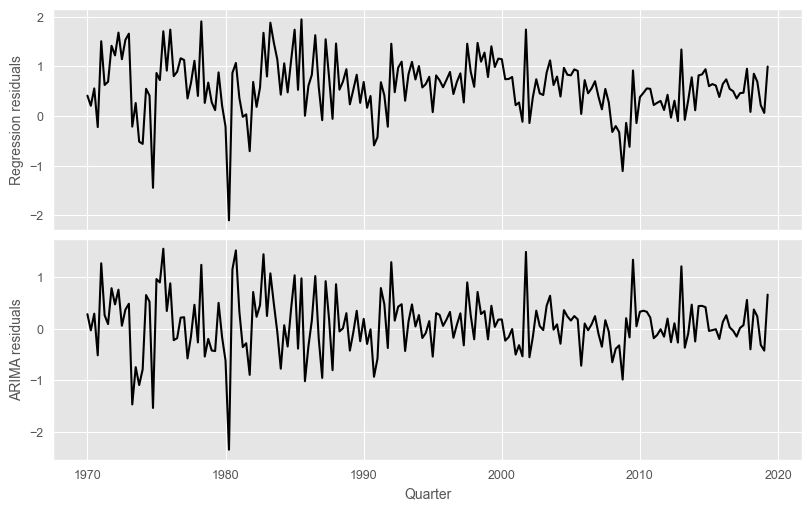

In [5]:
innov_resid = model["residuals"]
reg_resid = (us_change["Consumption"]
    - regr["ex_1"] * us_change["Income"])
    #- regr["intercept"])
resid = pd.DataFrame({
    "ARIMA residuals": innov_resid,
    "Regression residuals": reg_resid,
    "ds": us_change["ds"],
})

fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=resid, x="ds", y="Regression residuals", color="black",
    ax=axes[0])
sns.lineplot(data=resid, x="ds", y="ARIMA residuals", color="black",
    ax=axes[1])
axes[1].set(xlabel='Quarter')
plt.show()

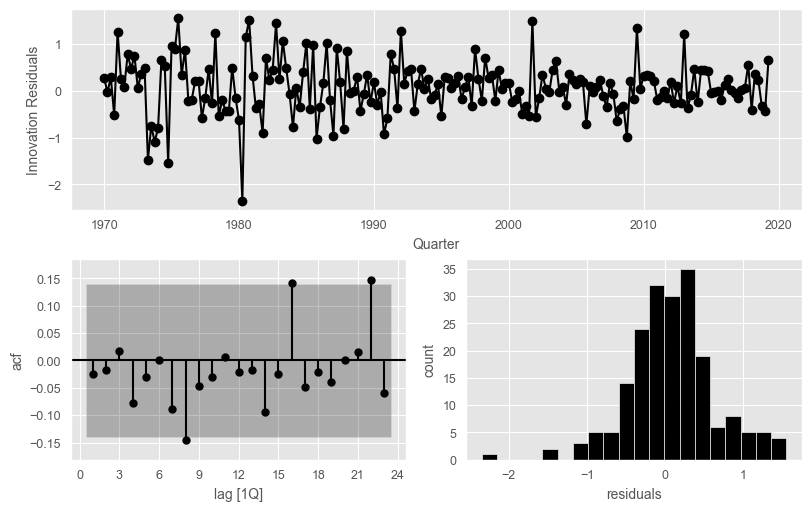

In [6]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(resid["ds"], innov_resid, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(innov_resid, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(innov_resid, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [7]:
ljung_box = acorr_ljungbox(innov_resid, lags=[8], model_df=3)
ljung_box

,lb_stat,lb_pvalue
8,7.66,0.176


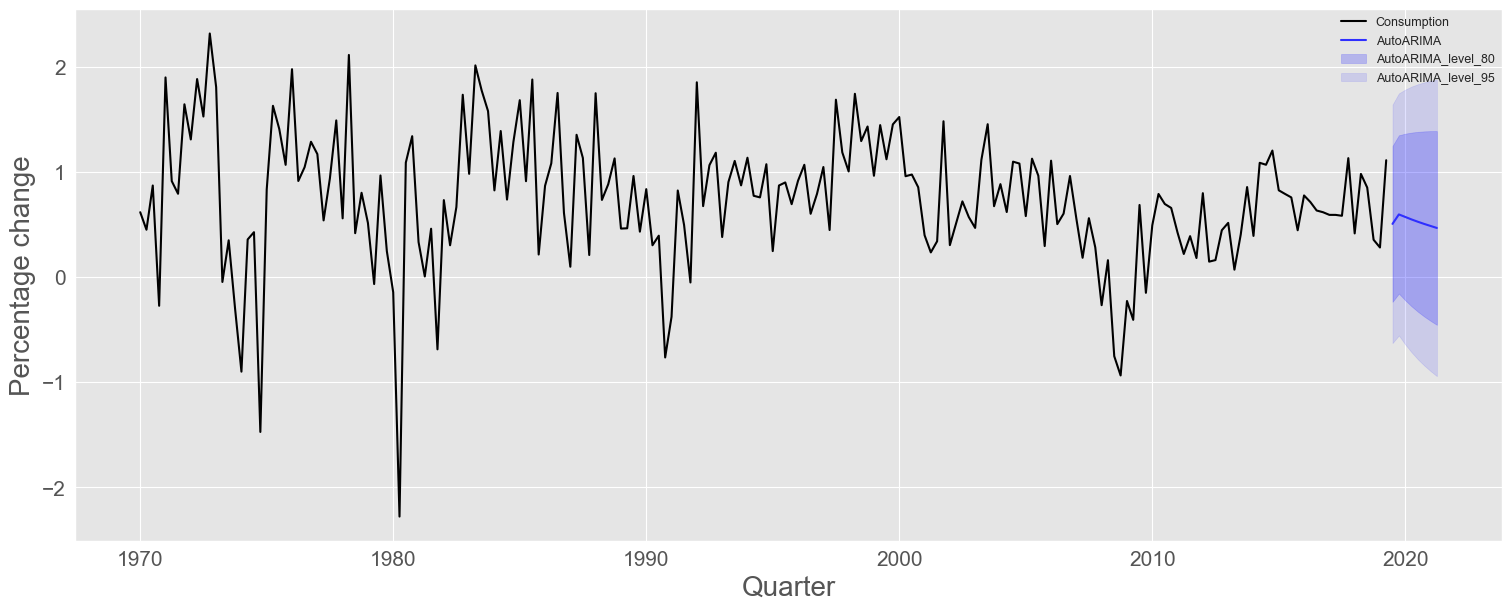

In [8]:
sf = StatsForecast(models=[AutoARIMA()], freq="QS")
uids = us_change["unique_id"].unique()
last_times = us_change[["ds"]].max()
future_predictors = (
    make_future_dataframe(uids, last_times, freq="QS", h=8)
    .assign(Income=us_change["Income"].mean())
)
level = [80, 95]
fc = sf.forecast(df=us_change, h=8,
    X_df=future_predictors, target_col="Consumption",
    fitted=True, level=level)
plot_series(us_change, fc, target_col="Consumption", level=level,
    title="", xlabel="Quarter", ylabel="Percentage change",
    palette="black_and_blue", rm_legend=False)

In [9]:
vic_elec = (
    pd.read_csv('vic_elec.csv', parse_dates=['ds'])
    .loc[lambda x: x["ds"] >= "2014"]
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index(level="Holiday").rename_axis(None, axis="columns")
)
vic_elec_daily = (
    vic_elec
    .resample("D")
    .agg({"Demand": "sum", "Temperature": "max", "Holiday": "first"})
    .reset_index()
    .assign(
        unique_id="VIC",
        Demand=lambda x: x["Demand"] / 1e3,
        Weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Day_Type=lambda x: np.select(
            [x["Holiday"], ~x["Holiday"] & x["Weekend"]],
            ["Holiday", "Weekend"],
            default="Weekday",
        )
    )
)

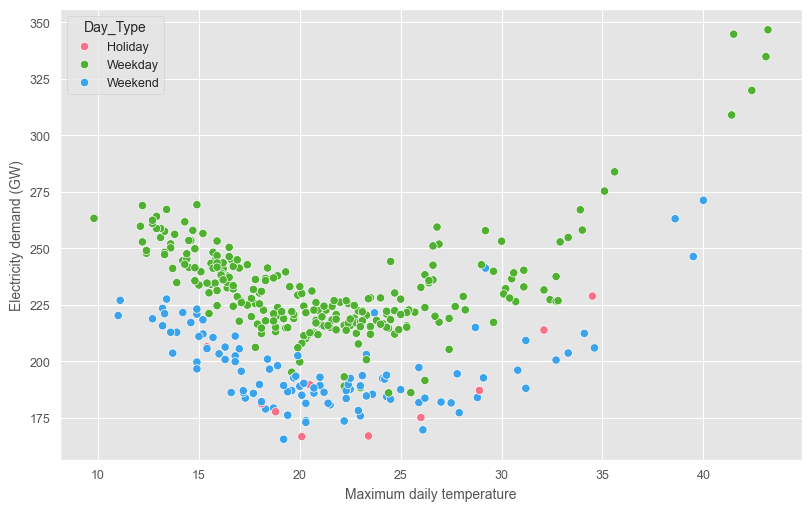

In [10]:
fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_daily,
  x="Temperature", y="Demand", hue="Day_Type")
ax.set(
  xlabel="Maximum daily temperature", ylabel="Electricity demand (GW)"
)
plt.show()

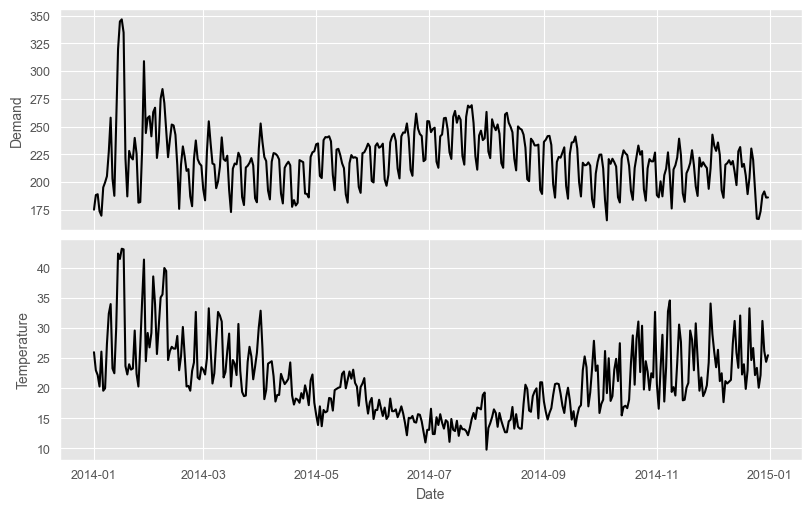

In [11]:
fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=vic_elec_daily, x='ds', y='Demand',
    color='black', ax=axes[0])
sns.lineplot(data=vic_elec_daily, x='ds', y='Temperature',
    color='black', ax=axes[1])
axes[1].set(xlabel="Date")
plt.show()

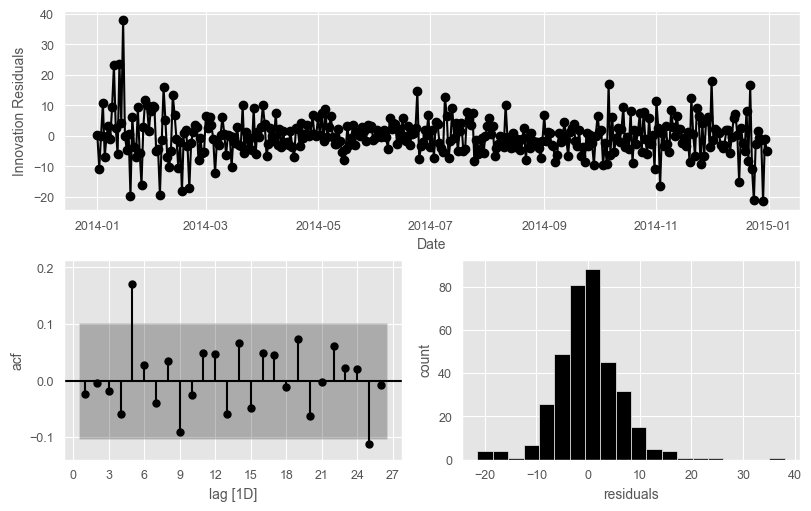

In [12]:
sf = StatsForecast(models=[AutoARIMA(season_length=7)], freq="D")
ex_columns = ["unique_id", "ds", "Demand", "Temperature"]
vic_elec_daily_ex = vic_elec_daily[ex_columns].assign(**{
    "Weekday": vic_elec_daily["Day_Type"] == "Weekday",
    "Temperature**2": vic_elec_daily["Temperature"]**2,
})
sf = sf.fit(df=vic_elec_daily_ex, target_col="Demand")
resids = sf.fitted_[0, 0].model_["residuals"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(vic_elec_daily["ds"], resids, marker="o")
axes["resid"].set(xlabel="Date", ylabel="Innovation Residuals")
plot_acf(resids, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1D]", ylabel="acf", title="")
axes["hist"].hist(resids, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [13]:
model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:8]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[8:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(2,1,2)(2,0,2)[7] errors 

      ARMA Coefficients
ar1              -0.087
ar2               0.716
ma1              -0.024
ma2              -0.914
sar1              0.309
sar2              0.566
sma1             -0.164
sma2             -0.386 

      Regression Coefficients
ex_1                   -7.501
ex_2                   29.325
ex_3                    0.178 

         Metrics
sigma^2    43.06
loglik  -1197.38
aic      2418.77
aicc     2419.66
bic      2465.53


In [14]:
ljung_box = acorr_ljungbox(resids, lags=[14], model_df=8)
ljung_box

,lb_stat,lb_pvalue
14,21.87,0.001


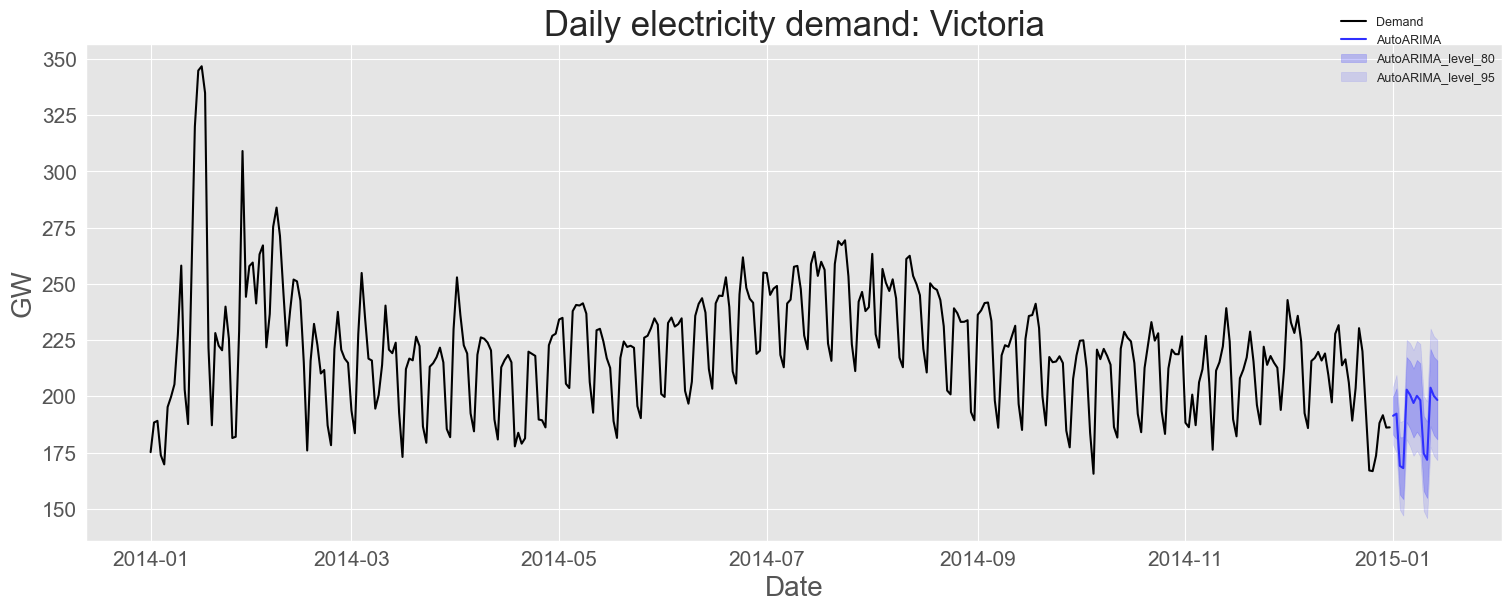

In [15]:
uids = vic_elec_daily_ex["unique_id"].unique()
last_times = vic_elec_daily_ex[["ds"]].max()
future_predictors = (
    make_future_dataframe(uids, last_times, freq="D", h=14)
    .assign(**{
        "Weekday": lambda x: ~x["ds"].dt.dayofweek.isin([5, 6]),
        "Temperature": 26,
        "Temperature**2": 26**2,
    })
)
level = [80, 95]
# Ensure column order agrees with usage above in sf.fit()
columns = vic_elec_daily_ex.columns.drop('Demand')
fc = sf.predict(h=14, X_df=future_predictors[columns], level=level)

plot_series(vic_elec_daily_ex, fc, target_col="Demand", level=level,
    xlabel="Date", ylabel="GW",
    title="Daily electricity demand: Victoria",
    palette="black_and_blue", rm_legend=False)

In [16]:
aus_airpassengers = (
    pd.read_csv('aus_airpassengers.csv', parse_dates=['Year'])
    [['Year', 'Passengers']]
    .rename(columns={'Year':'ds', 'Passengers':'y'})
    .assign(unique_id="aus_airpassengers")
)

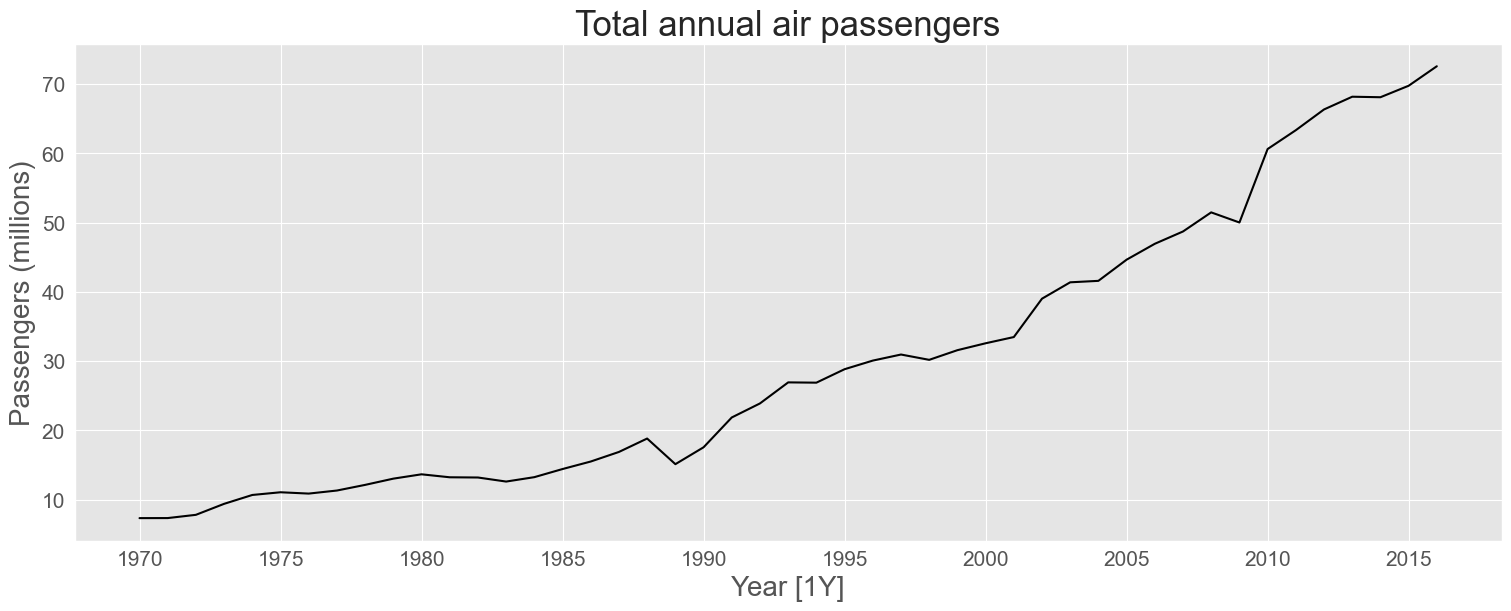

In [17]:
plot_series(aus_airpassengers,
    xlabel="Year [1Y]",
    ylabel="Passengers (millions)",
    title="Total annual air passengers",
    palette="black"
)

In [18]:
train_df, future_df = trend(aus_airpassengers, freq='YS', h=20)
train_df["intercept"] = 1
future_df["intercept"] = 1
model = AutoARIMA(d=0, alias="AutoARIMA_det")
sf = StatsForecast(models=[model], freq="YS")
sf = sf.fit(df=train_df)
fc_det = sf.predict(h=20, X_df=future_df, level=[80, 95])

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ValueError: xreg is rank deficient

In [19]:
model = AutoARIMA(d=1, alias="AutoARIMA_stoch")

sf = StatsForecast(models=[model], freq="YS")
sf = sf.fit(df=aus_airpassengers)
fc_stoch = sf.predict(h=20, level=[80, 95])

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs = pd.Series(coefs, name="Coefficients").round(3)

metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(3,1,0)                    

     Coefficients
ar1         0.128
ar2         0.270
ar3         0.262 

         Metrics
sigma^2     5.04
loglik   -101.18
aic       210.35
aicc      211.33
bic       217.67


In [20]:
df = fc_stoch.merge(fc_det, on=['unique_id', 'ds'])
plot_series(aus_airpassengers, df, level=[95],
    xlabel="Year [1Y]", ylabel="Air passengers (millions)",
    title="Forecasts from trend models",
    palette="black_and_2color", rm_legend=False,
    legend_loc="outside lower center")

NameError: name 'fc_det' is not defined

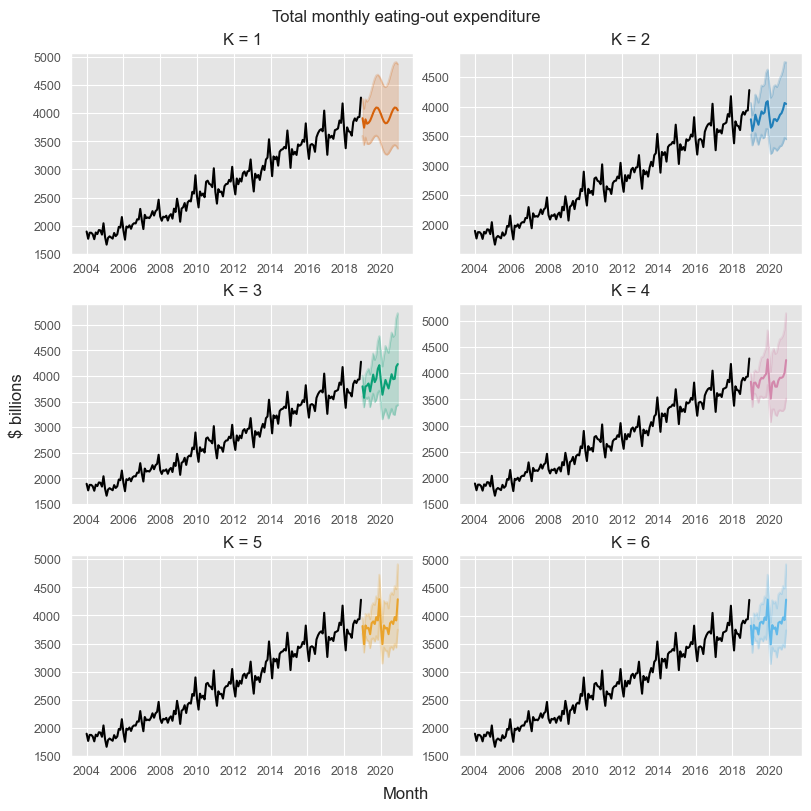

In [21]:
industry = "Cafes, restaurants and takeaway food services"
aus_cafe_df = (
    pd.read_csv("aus_retail.csv", parse_dates=["Month"])
    .loc[lambda x: x["Month"].between("2004", "2018-12-01")
        & (x["Industry"] == industry)
    ]
    .rename(columns={"Month": "ds", "Turnover": "y"})
    .groupby("ds", as_index=False)
    .agg({"y": "sum"})
    .assign(unique_id="aus_cafe")
)

def arima_with_fourier(k):
    aus_cafe = aus_cafe_df.assign(y=np.log(aus_cafe_df["y"]))
    features = [partial(fourier, season_length=12, k=k)]
    aus_cafe, fut = pipeline(
        aus_cafe, features=features, freq="MS", h=24)
    model = AutoARIMA(season_length=12, seasonal=False)
    sf = StatsForecast(models=[model], freq="MS")
    result = sf.forecast(df=aus_cafe, h=24, X_df=fut, level=[80, 95])
    numerics = result.select_dtypes(include=np.number)
    result[numerics.columns] = numerics.apply(np.exp)
    result["unique_id"] = "K=" + str(k)
    return result

def plot_with_intervals(ax, result, color):
    lo, mid, hi = "AutoARIMA-lo-95", "AutoARIMA", "AutoARIMA-hi-95"
    sns.lineplot(data=aus_cafe_df, x="ds", y="y", ax=ax, color="black")
    sns.lineplot(data=result, x="ds", y=mid, ax=ax, color=color)
    sns.lineplot(data=result, x="ds", y=lo, ax=ax, color=color, alpha=0.2)
    sns.lineplot(data=result, x="ds", y=hi, ax=ax, color=color, alpha=0.2)
    ax.fill_between(result["ds"], result[lo], result[hi],
        color=color, alpha=0.2)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("K = " + str(i + 1))

fig, axes = plt.subplots(3, 2, figsize=(8, 8))
colors = ["#d6610a", "#207fb9", "#0aa076", "#d388ac", "#e9a32b", "#62b9e9"]
for i, (ax, color) in enumerate(zip(axes.flat, colors)):
    result = arima_with_fourier(i + 1)
    plot_with_intervals(ax, result, color)
fig.suptitle("Total monthly eating-out expenditure")
fig.supylabel("$ billions")
fig.supxlabel("Month")
plt.show()

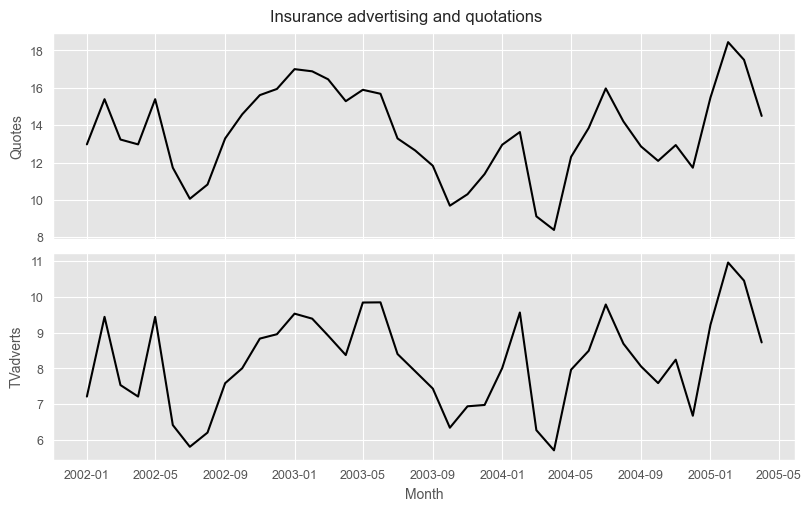

In [22]:
insurance = pd.read_csv('insurance.csv', parse_dates=['ds'])
fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=insurance, x="ds", y="Quotes",
    ax=axes[0], color="black")
sns.lineplot(data=insurance, x='ds', y='TVadverts',
    ax=axes[1], color='black')
axes[1].set(xlabel="Month")
fig.suptitle("Insurance advertising and quotations")
plt.show()

In [23]:
train = (
    insurance.assign(**{
        f"TVadverts_{lag}": insurance["TVadverts"].shift(lag)
        for lag in (1, 2, 3)
    })
    .assign(Quotes=insurance.Quotes.iloc[4:])
)

base_columns = ["unique_id", "ds", "Quotes", "TVadverts"]
lag_columns = ["TVadverts_1", "TVadverts_2", "TVadverts_3"]
model = AutoARIMA(season_length=12, d=0)
sfs = [
    StatsForecast(models=[model], freq='MS').fit(
        df=train[[*base_columns, *lag_columns[:n]]], target_col="Quotes")
    for n in range(4)
]

In [24]:
df = pd.DataFrame([
    {"model": f"lag{i}", "aicc": sf.fitted_[0, 0].model_["aicc"]}
    for (i, sf) in enumerate(sfs)
])
df.round(2)

,model,aicc
0,lag0,70.45
1,lag1,58.43
2,lag2,61.53
3,lag3,64.71


In [25]:
fit_df = insurance.assign(**{
    f"TVadverts_{lag}": insurance["TVadverts"].shift(lag)
    for lag in (1, 2, 3)
})
sf = StatsForecast(models=[AutoARIMA(d=0)], freq='MS')
fit_columns = ["unique_id", "ds", "Quotes", "TVadverts", "TVadverts_1"]
sf.fit(df=fit_df[fit_columns].dropna(), target_col="Quotes")

model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:2]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[2:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(3,0,0) errors 

     ARMA Coefficients
ar1              1.265
ar2             -0.780 

      Regression Coefficients
ar3                     0.352
ex_1                    1.373
ex_2                    0.259 

         Metrics
sigma^2     0.24
loglik    -25.79
aic        63.58
aicc       66.21
bic        73.56


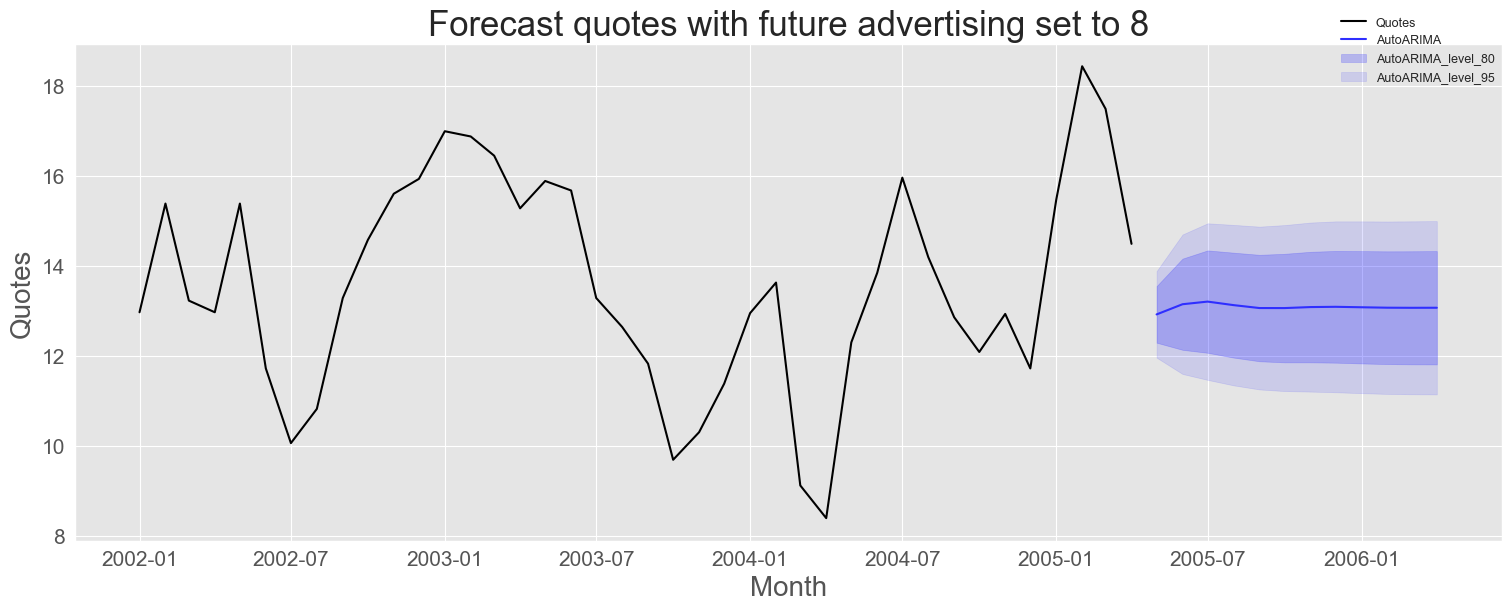

In [26]:
uids = insurance["unique_id"].unique()
last_times = insurance[["ds"]].max()
future_predictors = (
    make_future_dataframe(uids, last_times, freq="MS", h=12)
    .assign(TVadverts=8, TVadverts_1=8)
)
sf.fit(df=fit_df[fit_columns].dropna(), target_col="Quotes")
fc = sf.predict(h=12, X_df=future_predictors, level=[80,95])
plot_series(insurance, fc, level=[80,95], target_col="Quotes",
    xlabel="Month", ylabel="Quotes",
    title="Forecast quotes with future advertising set to 8",
    palette="black_and_blue", rm_legend=False)